In [1]:
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues, poisson
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

First define:

$r_t = \mu_t + \sigma_t u_t$, where $r_t = p_t - p_{t-1}$ (log return) such that $p_t = log(P_t)$. $u_t$ is an innovation let it be standard normal however we could use student innovations as well. There are a couple of ways to simulate the spot price from this:
- First let us use the $\sigma_t$ value in GBM and simulate the spot price $S_t$ under the SDE.

$dS_t = \mu S_t dt + \sigma_t S_t dW_t$ [1].

- Second, since we compute log returns in our volatility simulations anyway, let us consider the dynamics of the log price $\text{log}S_t$.

$d\text{log}S_t = (\mu - 0.5\sigma_t^2) dt + \sigma_t dW_t$ [2].

Focusing on the volatility process we have two different variances denoted $\sigma_i \,\, \forall i \in \{1, \dots, m\}$ such that we have $m$ regimes. We have a transition matrix denoted $\mathbf{P}$ that controls movement between regimes, this is set a priori (or estimated when calibrating) with some persistence to remain in same regime. For this version we set $m=2$. Any innovations can be used but here let us have standard normal innovations to agree with prices formula. 

We will use the GARCH(1, 1) specification for both here too. Other specifications easy just sum $\alpha_i r_{t-i}$ for however many lags you would like (i's). So given:

$\sigma^2_{1, t} = \omega_1 + \alpha_1 r_{t-1}^2 + \beta_1 \sigma_{1, t-1}^2$

$\sigma^2_{2, t} = \omega_2 + \alpha_2 r_{t-1}^2 + \beta_2 \sigma_{2, t-1}^2$. 

The volatility we input into our $r_t = \sigma_t u_t$ formula will be given as $\sigma^2_t = \mathbf{P} \vec{\sigma}^2_{t}$. !! This is only when we were forecasting, for a simulation we keep track of the regime state based on transition matrix then compute **one** $h_t$ based on parameters that align with regime we are in. 


In [2]:
def simulate_ms_garch(alpha, beta, omega, P, N, S0, h0):

    r = np.zeros(N)
    h = np.zeros(N)
    h[0] = h0
    regimes = np.zeros(N)
    logS = np.zeros(N)
    logS[0] = np.log(S0)

    for t in range(N):

            if t==0: 
                r[t] = np.sqrt(h[t]) * norm.rvs()

            else:
                u = np.random.rand()
                current_regime = regimes[t-1]
                if current_regime == 0:
                    if u <= P[0, 0]:
                        regimes[t] = 0
                    else:
                        regimes[t] = 1
                else:
                    if u <= P[1, 1]:
                        regimes[t] = 1
                    else:
                        regimes[t] = 0

                ''' For more than two states use the code: np.random.choice(m, p=P[current_regime])'''
                idx_regime = int(regimes[t])

                h[t] = omega[idx_regime] + alpha[idx_regime] * r[t-1] ** 2 + beta[idx_regime] * h[t-1]
                r[t] = np.sqrt(h[t]) * norm.rvs() #the log return 
                logS[t] = logS[t-1] - 0.5 * h[t] + r[t]

    S = np.exp(logS)

    return r, h, regimes, S


In [4]:
def simulate_ms_garch_with_jumps(alpha, beta, omega, P, N, S0, h0, lamb, mu_z, sigma_z):

    r = np.zeros(N)
    h = np.zeros(N)
    h[0] = h0
    regimes = np.zeros(N)
    logS = np.zeros(N)
    logS[0] = np.log(S0)

    for t in range(N):

            if t==0: 
                r[t] = np.sqrt(h[t]) * norm.rvs()

            else:
                u = np.random.rand()
                current_regime = regimes[t-1]
                if current_regime == 0:
                    if u <= P[0, 0]:
                        regimes[t] = 0
                    else:
                        regimes[t] = 1
                else:
                    if u <= P[1, 1]:
                        regimes[t] = 1
                    else:
                        regimes[t] = 0

                ''' For more than two states use the code: np.random.choice(m, p=P[current_regime])'''
                idx_regime = int(regimes[t])

                dN = poisson.rvs(mu = lamb)
                dJ = mu_z * dN + sigma_z * np.sqrt(dN) * norm.rvs()

                h[t] = omega[idx_regime] + alpha[idx_regime] * r[t-1] ** 2 + beta[idx_regime] * h[t-1]
                r[t] = np.sqrt(h[t]) * norm.rvs() + dJ #only add this as zero mean otherwise only innovation part added
                logS[t] = logS[t-1] - 0.5 * h[t] + r[t]

    S = np.exp(logS)

    return r, h, regimes, S


In [2]:
def simulate_garch(alpha, beta, omega, N, S0, h0):

    r = np.zeros(N)
    h = np.zeros(N)
    h[0] = h0
    logS = np.zeros(N)
    logS[0] = np.log(S0)

    for t in range(N):

            if t==0: 
                r[t] = np.sqrt(h[t]) * norm.rvs()

            else:

                h[t] = omega + alpha* r[t-1] ** 2 + beta * h[t-1]
                r[t] = np.sqrt(h[t]) * norm.rvs() #the log return 
                logS[t] = logS[t-1] - 0.5 * h[t] + r[t]

    S = np.exp(logS)

    return r, h, S


In [5]:
# feasible garch params
sigma = np.array([0.08 / np.sqrt(252), 0.3 / np.sqrt(252)])

alpha = np.array([0.05, 0.25])
beta = np.array([0.02, 0.1])

omega = sigma**2 * (1 - alpha - beta)
P = np.array([[0.92, 0.08], [0.14, 0.86]]) # stay in regime 0 wp 0.92 etc

N = 10_000
npaths = 500
m = 2
r_t = np.zeros((N, npaths))
h_t = np.zeros((N, npaths))
regimes = np.zeros((N, npaths))
#arbitrary but just start in regime 0
h0 = sigma[0] ** 2
S_t = np.zeros((N, npaths))
S0 = 10
M = 100 # small burn in to reach stat dist

#jumps with daily version
dt = 1/252
mu_z = 0.0 * dt # asymmetry - negative so on average jumps negative
sigma_z = 0.15 * dt # width of jumps
lamb = 0.5 * dt# model parameters of the jump part (NCPP)  - affects number of jumps

In [ ]:
# feasible garch params
sigma = np.array([0.08 / np.sqrt(252)])

alpha = np.array([0.05])
beta = np.array([0.92])

omega = sigma**2 * (1 - alpha - beta)

N = 4_000
npaths = 500
r_t = np.zeros((N, npaths))
h_t = np.zeros((N, npaths))
regimes = np.zeros((N, npaths))
#arbitrary but just start in regime 0
h0 = sigma[0] ** 2
S_t = np.zeros((N, npaths))
S0 = 10
M = 100 # small burn in to reach stat dist

#jumps with daily version
dt = 1/252
mu_z = 0.0 * dt # asymmetry - negative so on average jumps negative
sigma_z = 0.15 * dt # width of jumps
lamb = 0.5 * dt# model parameters of the jump part (NCPP)  - affects number of jumps

In [17]:
for i in range(npaths):
    r_t[:, i], h_t[:, i], S_t[:, i] = simulate_garch(alpha, beta, omega, N, S0, h0)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_23100/1433665107.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  h[t] = omega + alpha* r[t-1] ** 2 + beta * h[t-1]


In [7]:
for i in range(npaths):
    r_t[:, i], h_t[:, i], regimes[:, i], S_t[:, i] = simulate_ms_garch_with_jumps(alpha, beta, omega, P, N, S0, h0, lamb, mu_z, sigma_z)

In [18]:
np.savez("all_paths_garch2.npz", r=r_t, h=h_t, S=S_t)

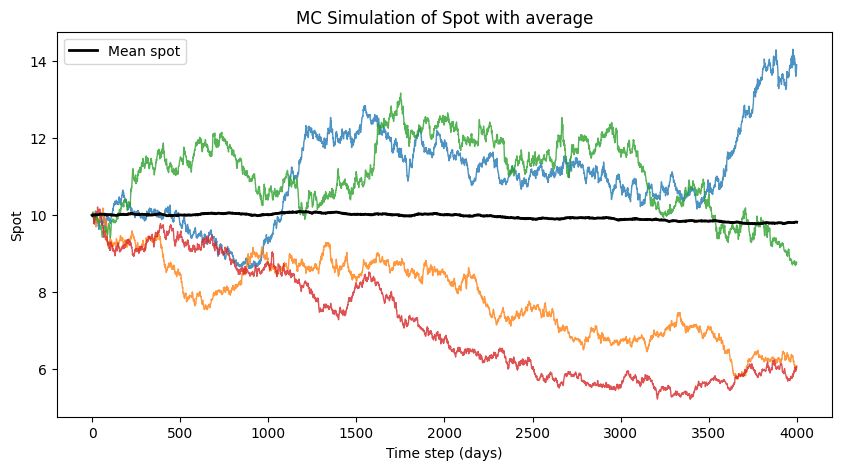

In [11]:
plt.figure(figsize=(10, 5))
for k in range(9, 13):
    plt.plot(S_t[:, k], linewidth = 1, alpha = 0.8)

mean_price = np.mean(S_t, axis = 1)
plt.plot(mean_price, "-k", label = "Mean spot", linewidth = 2)
plt.xlabel("Time step (days)")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average")
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_23100/1483780038.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


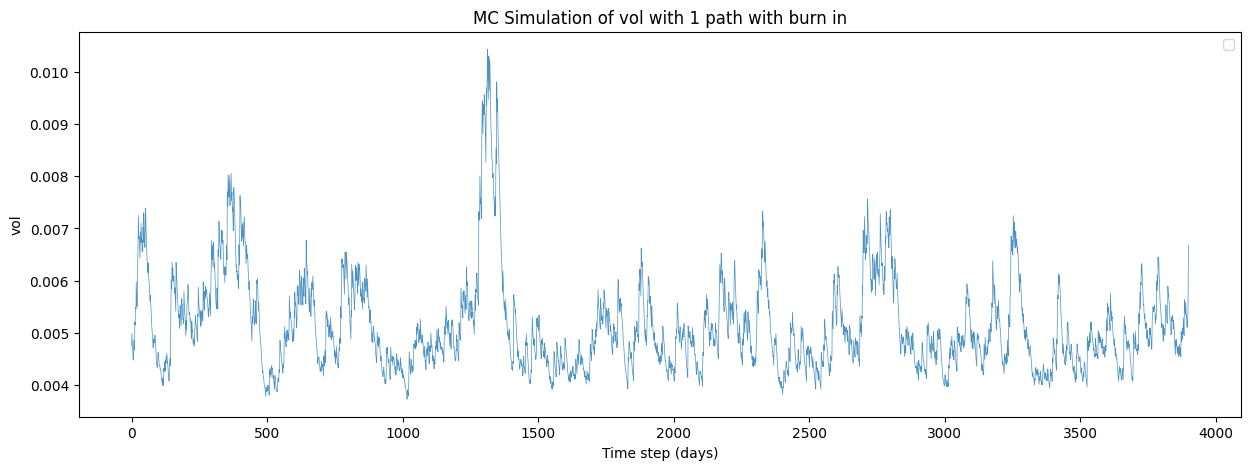

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(np.sqrt(h_t[M:, 0]), linewidth = 0.5, alpha = 0.8)

plt.xlabel("Time step (days)")
plt.ylabel("vol")
plt.title("MC Simulation of vol with 1 path with burn in")
plt.legend()

In [31]:
def compute_acf(x, lags):
    x_mean = x.mean()
    y = x - x_mean

    acf_vals = np.zeros(lags)
    acf_vals[0] = 1.0
    for i in range(1, lags):

        acf_vals[i] = (np.dot(y[i:], y[:-i])) / np.dot(y, y)

    return acf_vals

def get_confd_bands(n_obs, acfs, alpha = 0.05):
    '''
    Assuming underlying process is MA(q) we use this.
    '''


    K = len(acfs)
    z = norm.ppf(1 - alpha/2)
    lower = np.zeros(K)
    upper = np.zeros(K)

    for h in range(1, K):
        var_h = (1 + 2*np.sum(acfs[1:h]**2)) / n_obs
        halfwidth = z * np.sqrt(var_h)
        lower[h] = -halfwidth
        upper[h] =  halfwidth

    return lower, upper

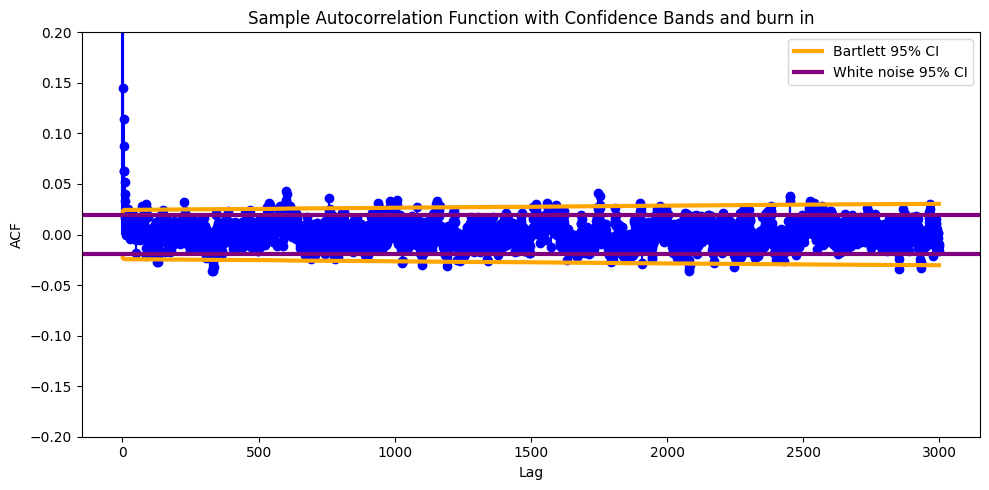

In [32]:
lags = 3000
x = abs(r_t[M:, 6])
n_obs = len(x)

acf_vals = compute_acf(x, lags)
lo, up = get_confd_bands(n_obs, acf_vals)

other = 1.96 / np.sqrt(n_obs)

plt.figure(figsize=(10, 5))
plt.stem(range(0, lags), acf_vals[0:], linefmt='b-', markerfmt='bo', basefmt=' ')
plt.plot(up[1:], '-',color = 'orange', linewidth = 3,  label = "Bartlett 95% CI")
plt.plot(lo[1:], "-", color = "orange", linewidth = 3)
plt.axhline(y = other, color = "purple", linewidth = 3, label = "White noise 95% CI")
plt.axhline(y = -other, color = "purple", linewidth = 3)
plt.ylim([-0.2, 0.2])
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Sample Autocorrelation Function with Confidence Bands and burn in')
plt.tight_layout()
plt.legend()
plt.show()

We see ACF values for short lags suggesting vol clustering. Interestingly, although slightly less, this looks sort of similar to MSM ACF plot - use MF-DFA to extract hurst and deside on long memeroy which it shuld not possess.

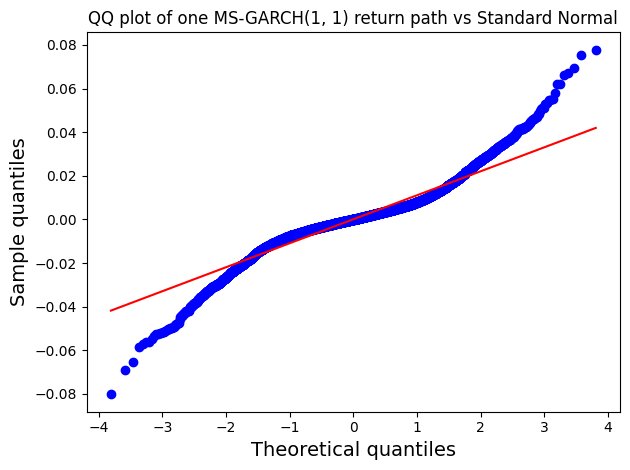

In [62]:
X = r_t[M:, 5]  # leave burn in 

stats.probplot(X, dist="norm", plot=plt)
plt.title("QQ plot of one MS-GARCH(1, 1) return path vs Standard Normal", fontsize = 12)
plt.xlabel("Theoretical quantiles", fontsize = 14)
plt.ylabel("Sample quantiles", fontsize = 14)
plt.tight_layout()
plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/QQplot_ms_garch")
plt.show()

In [34]:
Exkurts = np.zeros(npaths)
for i in range(npaths):
    Exkurts[i] = kurtosis(r_t[M:, i], fisher=True) 

print(f"Mean excess kurt over {npaths} paths: {Exkurts.mean()}")

Mean excess kurt over 500 paths: 4.339276573329728


We have fat tails - my FIGARCH params were lilkely too modest.

In [45]:
# as mentioned vol clustering will present itself as autocorreltaions at short lags
lags = 10

ps = []

for i in range(npaths):

    res = acorr_ljungbox(abs(r_t[M:, i]), lags = lags, return_df=True)
    ps.append(res['lb_pvalue'].iloc[-1])

print(f"Mean p-value of Ljung Box test: {np.mean(ps)}")

bonf_corr = 0.01 / npaths
print(f"Bonf Corr: {bonf_corr}")

Mean p-value of Ljung Box test: 0.0
Bonf Corr: 2e-05


In [46]:
fisher_p   = combine_pvalues(ps, method='fisher')[1]
fisher_p

np.float64(0.0)

In [19]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum

In [46]:
def get_hurst(data):
    '''
    Use my MF-DFA functions to get hurst exponent only.
    '''

    X = data
    N = len(X)
    s_min = 10
    s_max = len(X) // 4
    q = 2 # reccomended in lit for between -6 and 6
    m= 1
    steps = 40
    mu_X = np.mean(X)
    Y = np.cumsum(X - mu_X)

    F_q, ss, _, _, _ = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)

    H = get_generalised_hurst(F_q = F_q, ss = ss)

    return H

In [47]:
hursts_r = []
hursts_abs_r = []

for i in range(npaths):
    H_r = get_hurst(data = r_t[M:, i])
    H_abs_r = get_hurst(data = abs(r_t[M:, i]))
    hursts_r.append(H_r)
    hursts_abs_r.append(H_abs_r)    

In [48]:
print(f"Hurst average on returns: {np.mean(hursts_r)}")
print(f"Hurst average on absolute returns: {np.mean(hursts_abs_r)}")

Hurst average on returns: 0.49947887084632314
Hurst average on absolute returns: 0.6023025453582111


Intersting as some persistence - likely the vol clustering but definietly not as much as FIGARCH or MSM. 

## MF-DFA

Results should be v similar to FIGARCH in this. 

In [37]:
X = r_t[M:, 10] # leave burn in
N = len(X)
s_min = 10
s_max = len(X) // 4
qs = np.arange(-6, 7,1) # reccomended in lit for between -6 and 6
m= 1
steps = 40
mu_X = np.mean(X)
Y = np.cumsum(X - mu_X)

In [38]:
F_qs = list()
fitss1 = list()
fitss2 = list()

for q in qs: 

    F_q, ss, fits1, fits2, buffer = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)
    F_qs.append(F_q)
    
    if q == 2:
        
        fitss1.append(fits1)
        fitss2.append(fits2)

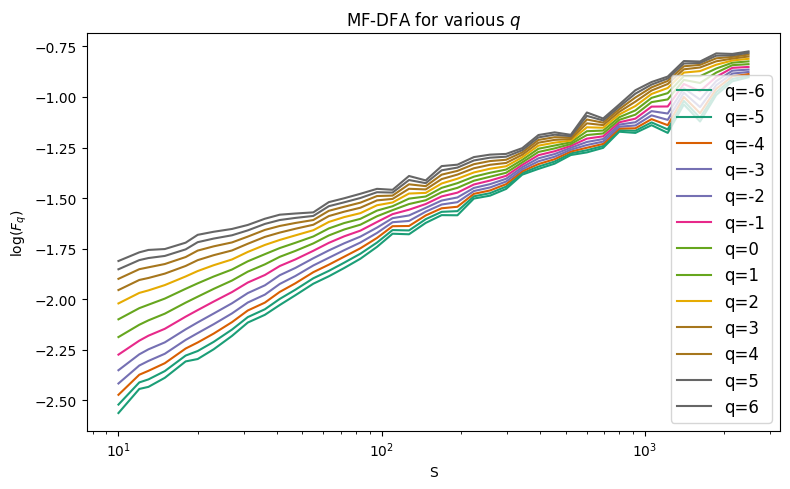

In [39]:
colors = plt.cm.Dark2(np.linspace(0, 1, len(qs)))

plt.figure(figsize = (8, 5))
for q_val, Fq, c in zip(qs, F_qs, colors):
    plt.plot((ss), np.log10(Fq), label=f'q={q_val}',  color = c, linewidth = 1.5)
plt.xscale('log')
plt.xlabel('S')
plt.ylabel(r'$\text{log}(F_q)$')
plt.title(r'MF-DFA for various $q$')
plt.legend(fontsize = "large")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Days')

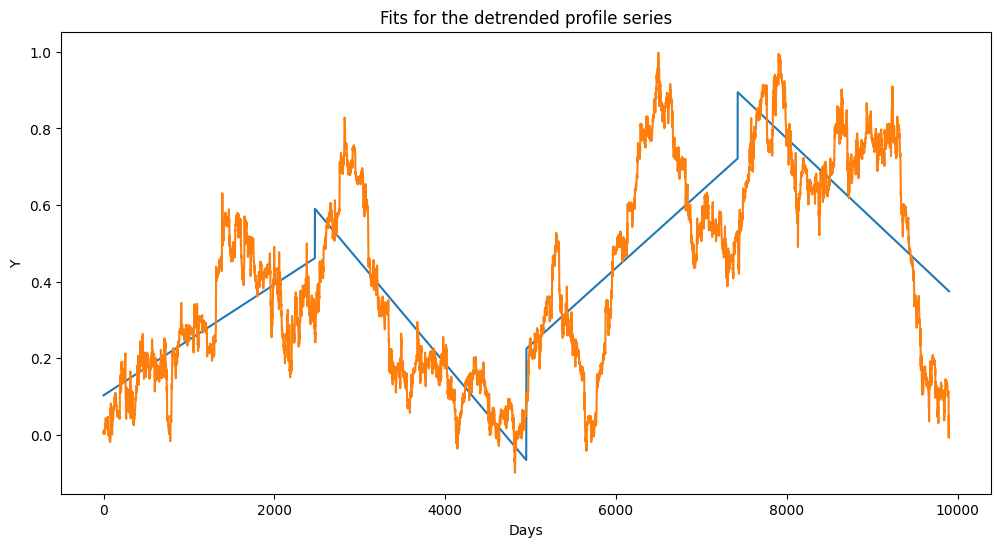

In [40]:
plt.figure(figsize = (12, 6))

y1 = np.concatenate(fitss1).flatten()
y2 = np.concatenate(fitss2).flatten()
t = np.arange(0, N, 1)
plt.plot(t, y1)
plt.plot(Y)
plt.title("Fits for the detrended profile series")
plt.ylabel("Y")
plt.xlabel("Days")

In [41]:
generalised_H = np.zeros(len(qs))

for i in range(len(F_qs)): 

    generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)

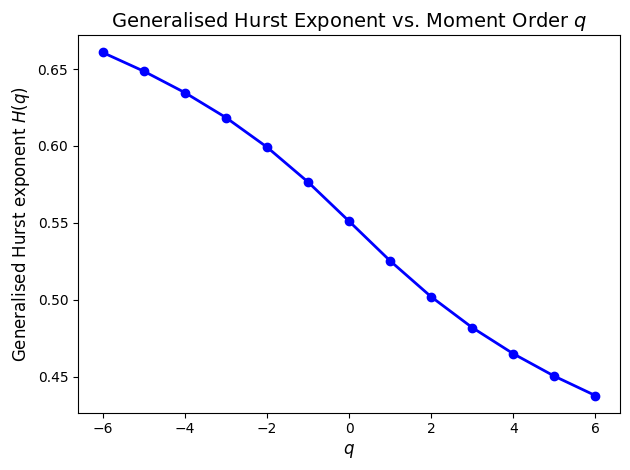

In [42]:
plt.plot(qs, generalised_H, linestyle='-', marker='o', markersize=6, linewidth=2, color='b')
plt.xlabel(r'$q$', fontsize=12)
plt.ylabel(r'Generalised Hurst exponent $H(q)$', fontsize=12)
plt.title(r'Generalised Hurst Exponent vs. Moment Order $q$', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)

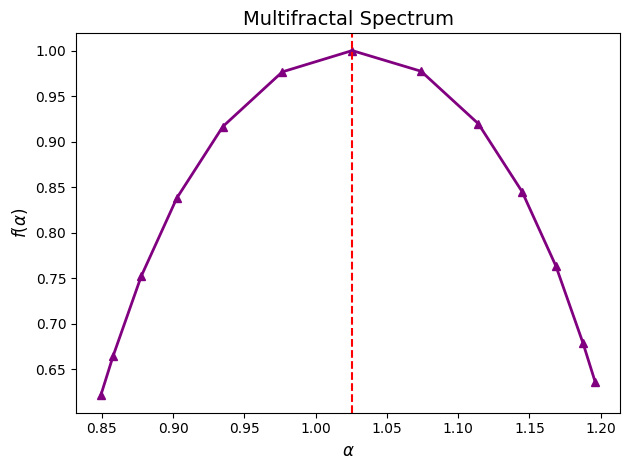

In [44]:
f_alpha_max_idx = np.argmax(f_alpha)

plt.plot(alpha_q, f_alpha, marker='^', markersize=6, linewidth=2, color='purple')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.title(r'Multifractal Spectrum', fontsize=14)
plt.axvline(x=alpha_q[f_alpha_max_idx], color='red', linestyle='--', label='max f_alpha')
plt.tight_layout()
plt.show()

MS-GARCH shows a wide multifractal spetcrum??